In [1]:
import numpy as np
import healpy
import healpy as hp
import pymaster as nmt
import matplotlib.pyplot as plt
from tqdm import trange

In [2]:
complexity = 'baseline' # 'baseline', 'medium_complexity' or 'high_complexity'
tracer = 'P' # 'P', 'B' or 'P_B'
fwhm = 10
fsky = 0.5
scale = 10

In [3]:
def masks(QU_template_for_mask,
          tracer = 'P', # 'P', 'B' or 'P_B'
          final_fsky = 85, 
          smooth_tracer_deg = 2, 
          apo_mask_deg = 2, 
          apo_type = 'C2', # NaMaster apodization type. If 'Gaussian', apodize with a Gaussian beam of fwhm given by apo_mask_deg.
          return_intermediate = False):

    if tracer == 'P':
        if smooth_tracer_deg!=0: 
            QU_template_for_mask_sm = healpy.sphtfunc.smoothing([0*QU_template_for_mask[0], 
                                                           QU_template_for_mask[0], 
                                                           QU_template_for_mask[1]], 
                                                           fwhm=np.radians(smooth_tracer_deg))
            
        else: QU_template_for_mask_sm = np.array([0*QU_template_for_mask[0],
                                                  QU_template_for_mask[0],
                                                  QU_template_for_mask[1]])

        template_for_mask_sm = np.sqrt(QU_template_for_mask_sm[1]**2+QU_template_for_mask_sm[2]**2)        

    elif tracer == 'B':         
        template_for_mask = np.abs(hp.alm2map(hp.map2alm([0*QU_template_for_mask[0],
                                                  QU_template_for_mask[0],
                                                  QU_template_for_mask[1]])[2], nside=hp.npix2nside(len(QU_template_for_mask[0])))
                                  )
        if smooth_tracer_deg!=0: 
            template_for_mask_sm = healpy.sphtfunc.smoothing(template_for_mask,
                                                           fwhm=np.radians(smooth_tracer_deg))
        else: template_for_mask_sm = template_for_mask
        
    elif tracer == 'P_B':     
        alm_B = hp.map2alm([0*QU_template_for_mask[0],
                            QU_template_for_mask[0],
                            QU_template_for_mask[1]])[2]
        QBUB_template_for_mask = hp.alm2map([alm_B, 0*alm_B, alm_B], nside=hp.npix2nside(len(QU_template_for_mask[0])))
        template_for_mask= np.sqrt(QBUB_template_for_mask[1]**2+QBUB_template_for_mask[2]**2)

        if smooth_tracer_deg!=0: 
            template_for_mask_sm = healpy.sphtfunc.smoothing(template_for_mask,
                                                           fwhm=np.radians(smooth_tracer_deg))
        else: template_for_mask_sm = template_for_mask
    
    N = int((1-final_fsky/100)*len(template_for_mask_sm))
    mask_raw = np.array(len(template_for_mask_sm)*[1])
    for i in np.argsort(np.abs(template_for_mask_sm))[-N:]:
        mask_raw[i] = 0
    
    if apo_mask_deg!=0:
        if apo_type == 'Gaussian':
            apo_mask = hp.smoothing(mask_raw, fwhm=np.radians(apo_mask_deg))
            apo_mask[apo_mask < 1e-5], apo_mask[apo_mask > 1] = 0, 1
        else:
            apo_mask = nmt.mask_apodization(mask_raw, aposize=apo_mask_deg, apotype=apo_type)
    else:
        apo_mask = mask_raw
    
    if return_intermediate: return apo_mask, mask_raw, template_for_mask_sm
    return apo_mask

In [4]:
path_mbs = f'/pscratch/sd/s/svinzl/B_modes_project/maps/maps_downgraded_nside64_e2e_{complexity}.npy'
QU_template = np.load(path_mbs)[0,0,-1]

fsky of apodized mask: 0.36398214980370147


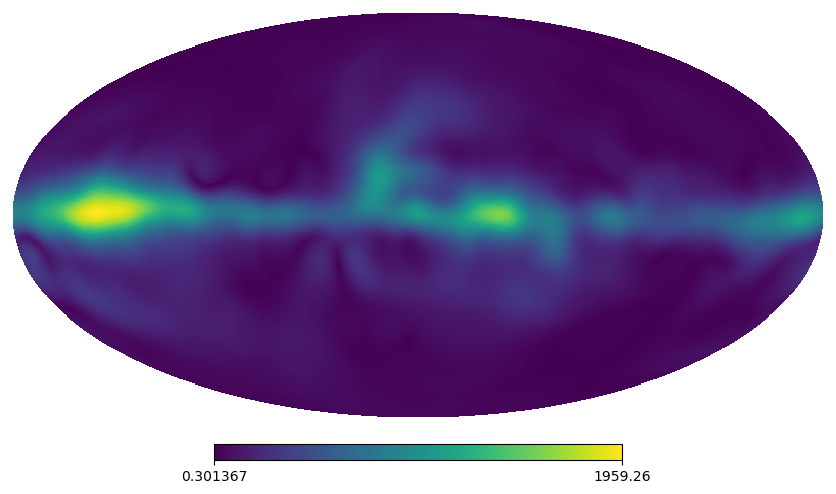

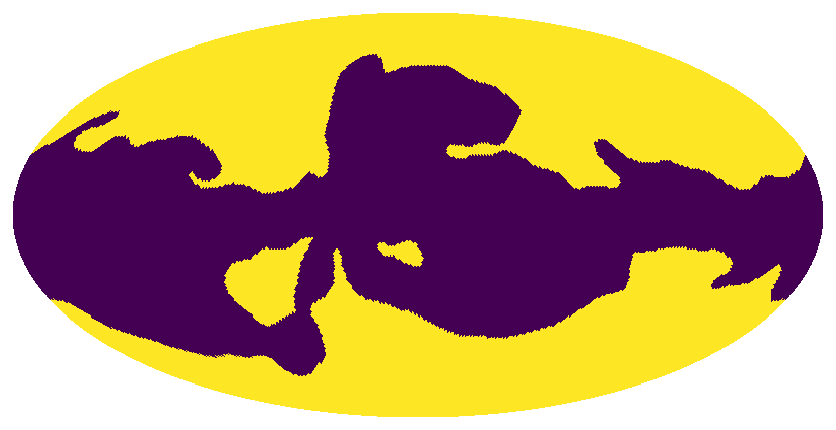

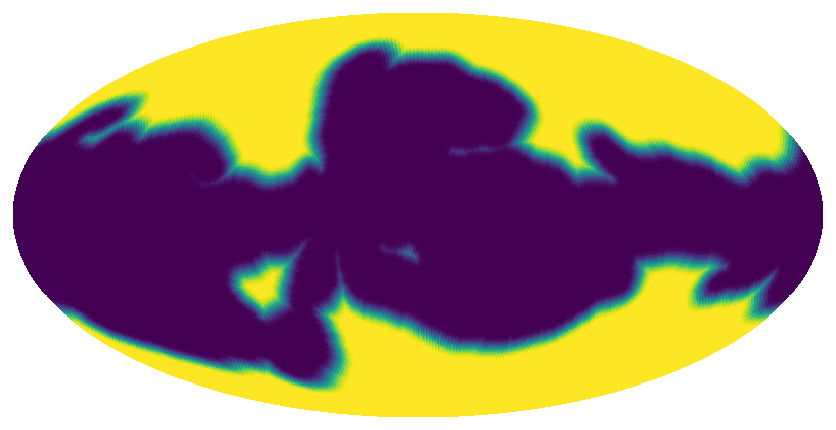

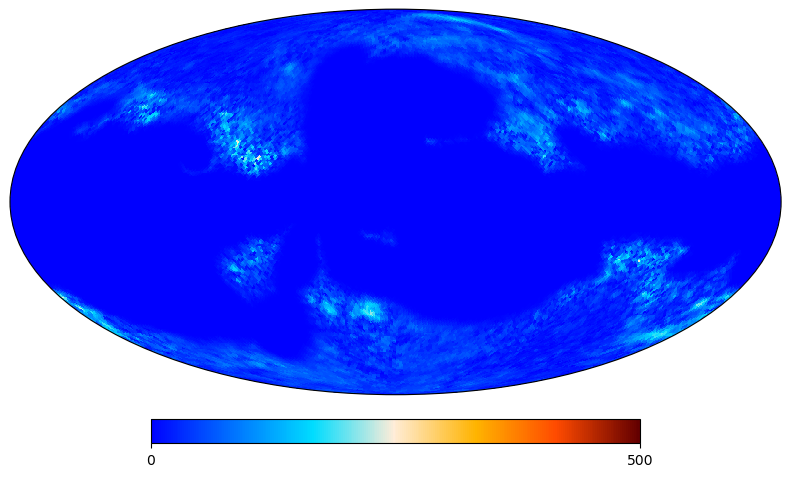

In [66]:
apo_mask, mask_raw, template_for_mask_sm = masks(QU_template,
          tracer = tracer,
          final_fsky = fsky*100, 
          smooth_tracer_deg = fwhm,
          apo_mask_deg = scale,
          apo_type = 'C2',
          return_intermediate = True)

hp.mollview(template_for_mask_sm, title=None)
hp.mollview(mask_raw, title=None, cbar=False)
hp.mollview(apo_mask, title=None, cbar=False)
hp.projview(apo_mask * np.sqrt(np.sum(QU_template**2, axis=0)), cmap='planck', min=0, max=500)

fsky_eff = np.mean(apo_mask**2)
print(f'fsky of apodized mask: {fsky_eff}')

In [67]:
# Bias of the power spectrum estimate

include_cmb = True # If False, test on fg-like only power spectrum
cmb_only = True
N = 1000
nside = 64
lmax = 3*nside-1
Nlbin = 10
lbin = 35

mask = apo_mask
purify = True
is_Dell = False

if lbin is None:
    b = nmt.NmtBin.from_lmax_linear(lmax=lmax, nlb=Nlbin, is_Dell=is_Dell) # Binning scheme for the cross-spectra
else:
    ell_ini = np.concatenate((np.arange(2, lbin), np.arange(lbin, lmax+1, Nlbin)))
    ell_end = np.concatenate((np.arange(2, lbin)+1, np.arange(lbin, lmax+1, Nlbin)+Nlbin))
    ell_end = ell_end[ell_end <= lmax+1]
    ell_ini = ell_ini[:len(ell_end)]
    b = nmt.NmtBin.from_edges(ell_ini, ell_end, is_Dell=is_Dell)
    b.lmax = lmax
    
leff = b.get_effective_ells()
Nbins = len(leff)

f = nmt.NmtField(mask, None, spin=2, lmax=lmax, purify_b=purify)
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f, f, b)

ell = np.arange(3*nside)[2:]

Cls_fg = np.zeros((4, 3*nside))
Cls_fg[2, 2:] = 0.1 * (ell/100)**(-2.5)
Cls_fg[1] = 2 * Cls_fg[2]

Cl_true_fg = np.zeros((4, 3*nside))
Cl_true_fg[0] = Cls_fg[1]
Cl_true_fg[3] = Cls_fg[2]
Dl_true_fg = w.decouple_cell(w.couple_cell(Cl_true_fg))[3]

if include_cmb:
    Cl_CMB = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')
    Cls_cmb = np.zeros((4, 3*nside))
    Cls_cmb[1], Cls_cmb[2] = Cl_CMB[1, :3*nside], Cl_CMB[2, :3*nside]

    Cl_true_cmb = np.zeros((4, 3*nside))
    Cl_true_cmb[0] = Cls_cmb[1]
    Cl_true_cmb[3] = Cls_cmb[2]
    Dl_true_cmb = w.decouple_cell(w.couple_cell(Cl_true_cmb))[3]
    
    Cls_theory = Cls_cmb + Cls_fg * (1-cmb_only)
else:
    Cls_theory = Cls_fg

Cl_true = np.zeros((4, 3*nside))
Cl_true[0] = Cls_theory[1]
Cl_true[3] = Cls_theory[2]
Dl_true = w.decouple_cell(w.couple_cell(Cl_true))[3]

Dl_BB = np.zeros((N, Nbins))

for k in trange(N):
    IQU = hp.synfast(Cls_theory, nside, new=True)

    f = nmt.NmtField(mask, IQU[1:], purify_b=purify)
    Cl_coupled = nmt.compute_coupled_cell(f, f)
    Dl_BB[k] = w.decouple_cell(Cl_coupled)[3]

Dl_BB_cmb = Dl_BB - Dl_true_fg * (1-cmb_only)

100%|██████████| 1000/1000 [01:19<00:00, 12.56it/s]


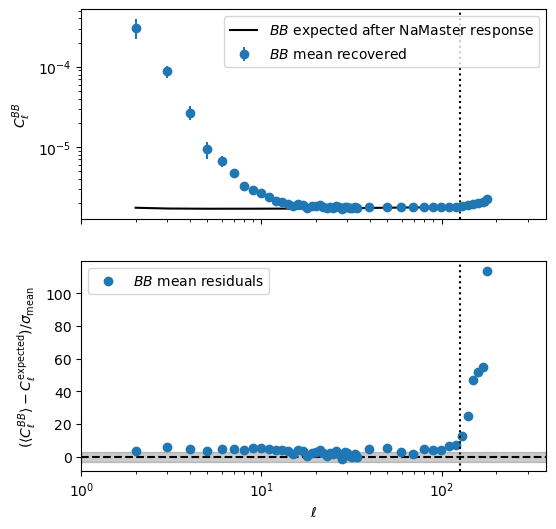

In [68]:
fig, ax = plt.subplots(2, sharex=True, figsize=(6, 6))

ax[0].plot(leff, Dl_true, label=r'$BB$ expected after NaMaster response', color='black')
ax[0].errorbar(leff, np.mean(Dl_BB, axis=0), yerr=np.std(Dl_BB, axis=0) / np.sqrt(N), fmt='o', label=r'$BB$ mean recovered')
ax[0].axvline(2*nside-1, linestyle='dotted', color='black')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$C_\ell^{BB}$')
ax[0].legend()

ax[1].fill_between(np.arange(min(ell)/2, 2*max(ell)), -3, 3, color='black', alpha=0.2)
ax[1].axhline(0, linestyle='--', color='black')
ax[1].plot(leff, (np.mean(Dl_BB, axis=0) - Dl_true) / (np.std(Dl_BB, 0) / np.sqrt(N)), 'o', label=r'$BB$ mean residuals')
ax[1].axvline(2*nside-1, linestyle='dotted', color='black')
ax[1].set_ylabel(r'$(\langle C_\ell^{BB} \rangle - C_\ell^{\rm expected}) / \sigma_{\rm mean}$')
ax[1].legend()

ax[1].set_xlabel(r'$\ell$')
ax[1].set_xlim(min(ell)/2, 2*max(ell))
plt.show()

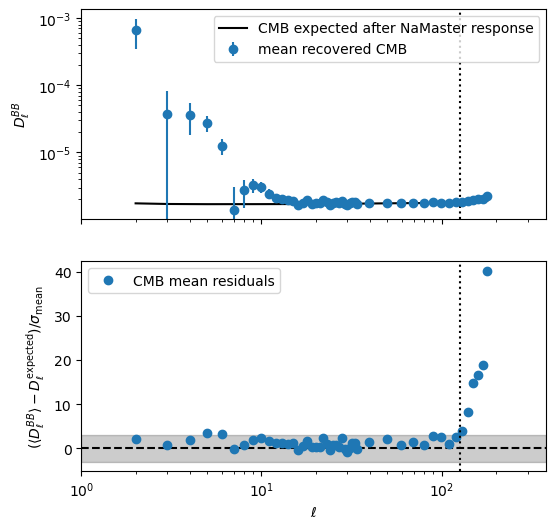

In [28]:
fig, ax = plt.subplots(2, sharex=True, figsize=(6, 6))

ax[0].plot(leff, Dl_true_cmb, label=r'CMB expected after NaMaster response', color='black')
ax[0].errorbar(leff, np.mean(Dl_BB_cmb, axis=0), yerr=np.std(Dl_BB_cmb, axis=0) / np.sqrt(N), fmt='o', label=r'mean recovered CMB')
ax[0].axvline(2*nside-1, linestyle='dotted', color='black')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$D_\ell^{BB}$')
ax[0].legend()

ax[1].fill_between(np.arange(min(ell)/2, 2*max(ell)), -3, 3, color='black', alpha=0.2)
ax[1].axhline(0, linestyle='--', color='black')
ax[1].plot(leff, (np.mean(Dl_BB_cmb, axis=0) - Dl_true_cmb) / (np.std(Dl_BB_cmb, 0) / np.sqrt(N)), 'o', label=r'CMB mean residuals')
ax[1].axvline(2*nside-1, linestyle='dotted', color='black')
ax[1].set_ylabel(r'$(\langle D_\ell^{BB} \rangle - D_\ell^{\rm expected}) / \sigma_{\rm mean}$')
ax[1].legend()

ax[1].set_xlabel(r'$\ell$')
ax[1].set_xlim(min(ell)/2, 2*max(ell))
plt.show()